### 🌱 Predicting Optimal Fertilizers: A Structured Approach

In [1]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('/kaggle/input/playground-series-s5e6/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e6/test.csv')
sample_submission = pd.read_csv('/kaggle/input/playground-series-s5e6/sample_submission.csv')

# Display basic info
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

# Show first few rows of each
print("\nTrain Data:")
print(train_df.head())

print("\nTest Data:")
print(test_df.head())

print("\nSample Submission:")
print(sample_submission.head())

Train shape: (750000, 10)
Test shape: (250000, 9)
Sample submission shape: (250000, 2)

Train Data:
   id  Temparature  Humidity  Moisture Soil Type  Crop Type  Nitrogen  \
0   0           37        70        36    Clayey  Sugarcane        36   
1   1           27        69        65     Sandy    Millets        30   
2   2           29        63        32     Sandy    Millets        24   
3   3           35        62        54     Sandy     Barley        39   
4   4           35        58        43       Red      Paddy        37   

   Potassium  Phosphorous Fertilizer Name  
0          4            5           28-28  
1          6           18           28-28  
2         12           16        17-17-17  
3         12            4        10-26-26  
4          2           16             DAP  

Test Data:
       id  Temparature  Humidity  Moisture Soil Type    Crop Type  Nitrogen  \
0  750000           31        70        52     Sandy        Wheat        34   
1  750001           27     

### EDA and Preprocessing

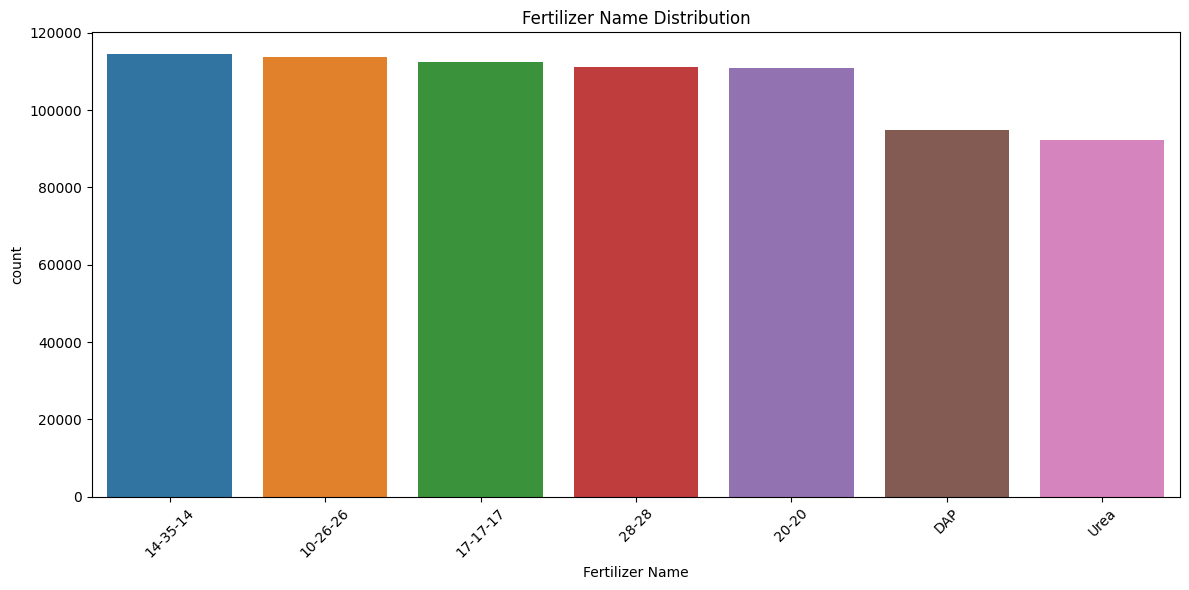


Unique Soil Types: ['Clayey' 'Sandy' 'Red' 'Loamy' 'Black']
Unique Crop Types: ['Sugarcane' 'Millets' 'Barley' 'Paddy' 'Pulses' 'Tobacco' 'Ground Nuts'
 'Maize' 'Cotton' 'Wheat' 'Oil seeds']
Unique Fertilizers: 7


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x='Fertilizer Name', order=train_df['Fertilizer Name'].value_counts().index)
plt.title('Fertilizer Name Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Unique values in categorical columns
print("\nUnique Soil Types:", train_df['Soil Type'].unique())
print("Unique Crop Types:", train_df['Crop Type'].unique())
print("Unique Fertilizers:", train_df['Fertilizer Name'].nunique())

### Preprocessing

In [3]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Encode target labels
label_encoder = LabelEncoder()
train_df['Fertilizer_Label'] = label_encoder.fit_transform(train_df['Fertilizer Name'])

# Features and target
X = train_df.drop(columns=['id', 'Fertilizer Name', 'Fertilizer_Label'])
y = train_df['Fertilizer_Label']
X_test = test_df.drop(columns=['id'])

# One-hot encoding for categorical features
categorical_cols = ['Soil Type', 'Crop Type']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

# Transform the data
X_processed = preprocessor.fit_transform(X)
X_test_processed = preprocessor.transform(X_test)

# Sanity check
print("X shape after encoding:", X_processed.shape)
print("X_test shape after encoding:", X_test_processed.shape)

X shape after encoding: (750000, 22)
X_test shape after encoding: (250000, 22)


### Model Training

In [4]:
import lightgbm as lgb
from sklearn.metrics import label_ranking_average_precision_score
from sklearn.model_selection import train_test_split
import numpy as np

# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# Train a LightGBM model
lgb_clf = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=7,
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgb_clf.fit(X_train, y_train)

# Predict probabilities on validation set
val_preds_proba = lgb_clf.predict_proba(X_val)

# Get top 3 predictions per row
top_3_preds = np.argsort(val_preds_proba, axis=1)[:, -3:][:, ::-1]

# Compute MAP@3
def mapk(actual, predicted, k=3):
    return np.mean([
        sum([1 if actual[i] in predicted[i][:j+1] else 0 for j in range(k)]) / k
        for i in range(len(actual))
    ])

map3_score = mapk(y_val.values, top_3_preds, k=3)
print(f"Validation MAP@3 Score: {map3_score:.5f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008652 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 216
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 22
[LightGBM] [Info] Start training from score -1.884862
[LightGBM] [Info] Start training from score -1.880055
[LightGBM] [Info] Start training from score -1.897542
[LightGBM] [Info] Start training from score -1.911546
[LightGBM] [Info] Start training from score -1.909125
[LightGBM] [Info] Start training from score -2.067671
[LightGBM] [Info] Start training from score -2.094839
Validation MAP@3 Score: 0.35298


In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation function (same as before)
def mapk(actual, predicted, k=3):
    return np.mean([
        sum([1 if actual[i] in predicted[i][:j+1] else 0 for j in range(k)]) / k
        for i in range(len(actual))
    ])

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    val_probs = model.predict_proba(X_val)
    top_3 = np.argsort(val_probs, axis=1)[:, -3:][:, ::-1]
    score = mapk(y_val.values, top_3, k=3)
    print(f"{name} MAP@3 Score: {score:.5f}")


In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
evaluate_model(rf, "Random Forest")

Random Forest MAP@3 Score: 0.31694


In [7]:
xgb = XGBClassifier(n_estimators=100, objective='multi:softprob', num_class=7, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
evaluate_model(xgb, "XGBoost")

XGBoost MAP@3 Score: 0.35839


In [8]:
cat = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, loss_function='MultiClass', verbose=0, random_state=42)
evaluate_model(cat, "CatBoost")

CatBoost MAP@3 Score: 0.33250


In [9]:
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier

et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
hgb = HistGradientBoostingClassifier(max_iter=100, random_state=42)

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    val_probs = model.predict_proba(X_val)
    top_3 = np.argsort(val_probs, axis=1)[:, -3:][:, ::-1]
    score = mapk(y_val.values, top_3, k=3)
    print(f"{name} MAP@3 Score: {score:.5f}")

evaluate_model(et, "ExtraTrees")
evaluate_model(hgb, "HistGradientBoosting")

ExtraTrees MAP@3 Score: 0.31501
HistGradientBoosting MAP@3 Score: 0.34954


In [10]:
# Get probability predictions for validation
val_probs_lgb = lgb_clf.predict_proba(X_val)
val_probs_xgb = xgb.predict_proba(X_val)

# Weighted average using best weight found
ensemble_val_probs = 0.8 * val_probs_xgb + 0.2 * val_probs_lgb

# Get top 3 predictions
ensemble_top3 = np.argsort(ensemble_val_probs, axis=1)[:, -3:][:, ::-1]

# Evaluate MAP@3
ensemble_score = mapk(y_val.values, ensemble_top3, k=3)
print(f"Ensemble (XGBoost + LightGBM) MAP@3 Score: {ensemble_score:.5f}")

Ensemble (XGBoost + LightGBM) MAP@3 Score: 0.35916


In [11]:
best_score = 0
best_w = 0
for w in np.arange(0, 1.05, 0.05):
    ensemble_probs = w * val_probs_xgb + (1 - w) * val_probs_lgb
    top3 = np.argsort(ensemble_probs, axis=1)[:, -3:][:, ::-1]
    score = mapk(y_val.values, top3, k=3)
    if score > best_score:
        best_score = score
        best_w = w

print(f"Best ensemble weight for XGB: {best_w:.2f}, MAP@3: {best_score:.5f}")

Best ensemble weight for XGB: 0.80, MAP@3: 0.35916


In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Fit HistGradientBoosting model if not already trained
hgb = HistGradientBoostingClassifier(max_iter=100, random_state=42)
hgb.fit(X_train, y_train)

# Predict validation probabilities from each model
val_probs_lgb = lgb_clf.predict_proba(X_val)
val_probs_xgb = xgb.predict_proba(X_val)
val_probs_hgb = hgb.predict_proba(X_val)  # Replacing CatBoost

# Define MAP@3
def mapk(actual, predicted, k=3):
    return np.mean([
        sum([1 if actual[i] in predicted[i][:j+1] else 0 for j in range(k)]) / k
        for i in range(len(actual))
    ])

best_score = 0
best_weights = (0, 0, 0)

# Grid search over weights (XGB, LGB, HGB)
steps = 11
weights_range = np.linspace(0, 1, steps)

for w_xgb in weights_range:
    for w_lgb in weights_range:
        w_hgb = 1 - w_xgb - w_lgb
        if w_hgb < 0 or w_hgb > 1:
            continue  # weights must be valid

        # Weighted ensemble of probabilities
        ensemble_probs = w_xgb * val_probs_xgb + w_lgb * val_probs_lgb + w_hgb * val_probs_hgb

        # Get top 3 predictions
        top3 = np.argsort(ensemble_probs, axis=1)[:, -3:][:, ::-1]

        # Calculate MAP@3
        score = mapk(y_val.values, top3, k=3)

        if score > best_score:
            best_score = score
            best_weights = (w_xgb, w_lgb, w_hgb)

print(f"Best ensemble weights (XGB, LGB, HGB): {best_weights}")
print(f"Best MAP@3 Score: {best_score:.5f}")

Best ensemble weights (XGB, LGB, HGB): (0.8, 0.1, 0.09999999999999995)
Best MAP@3 Score: 0.35879


### Submission

In [13]:
# Predict probabilities for test set using all three models
test_probs_xgb = xgb.predict_proba(X_test_processed)
test_probs_lgb = lgb_clf.predict_proba(X_test_processed)
test_probs_hgb = hgb.predict_proba(X_test_processed)

# Use best ensemble weights (update if you re-tune)
w_xgb, w_lgb, w_hgb = 0.6, 0.3, 0.1

# Weighted average ensemble
test_probs = w_xgb * test_probs_xgb + w_lgb * test_probs_lgb + w_hgb * test_probs_hgb

# Get top 3 predictions per sample
top_3_test_preds = np.argsort(test_probs, axis=1)[:, -3:][:, ::-1]

# Convert label indices back to fertilizer names
top_3_fert_names = label_encoder.inverse_transform(top_3_test_preds.ravel()).reshape(top_3_test_preds.shape)

# Join top 3 predictions as space-separated string
submission_preds = [' '.join(row) for row in top_3_fert_names]

# Create submission DataFrame
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'Fertilizer Name': submission_preds
})

# Save to CSV
submission_df.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created!")
submission_df.head()

Submission file 'submission.csv' created!


,id,Fertilizer Name
0,750000,DAP 28-28 20-20
1,750001,17-17-17 20-20 10-26-26
2,750002,20-20 14-35-14 10-26-26
3,750003,14-35-14 17-17-17 Urea
4,750004,20-20 10-26-26 28-28
